Used case for development: 

Incorporate drones with number of movements with current capacity.

- An introduction of these vehicles requires a potential shift in airspace. This because certain airspace is expected to not be accessible for drones given factors such as wake turbulence generated by conventional aircraft. As well as aircraft seperation requirements. 
- The main assumption for this case is that drone are introduced in 2025. 
- The second assumption relates to the number of movements when introduced in 2025. This is set to be XXXX annually. 

Incorporate eVTOL

- Just like drones, these new vehicles still require certain airspace 'corridors'. 
- Alongside airspace, this introduction will also have effect on the terminal design (passengers boarding etc). 
- The main assumption for this case is that eVTOL's are introduced in 2025. 
- The second assumption predefines the initial number of eVTOL movements - set to equate XXXX annually. 



In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

df = pd.read_csv('aerovale_demand.csv',delimiter=';')
df = df[~df['Year'].isin([2020, 2021, 2022])]


Exercise 1: Part 2:

In [11]:
def GBM(hist,Nscr = 1000,t_yrs_scr = 20,dt=1):
    historical = np.array(hist)
    r = np.log(historical[1:]/historical[:-1])
    Mu = np.mean(r)
    sig = np.std(r,ddof=1)
    y0 = hist[-1]
    eps = np.random.normal(0.0,1,size=(Nscr,t_yrs_scr))
    simulated_r = Mu*dt +sig*eps*np.sqrt(dt)
    logs = np.cumsum(simulated_r,axis=1)
    future_paths = y0 * np.exp(logs)
    total_len = len(hist) + t_yrs_scr
    ypaths = np.zeros((total_len, Nscr))
    ypaths[:len(hist), :] = historical[:, None]
    ypaths[len(hist):, :] = future_paths.T
    return ypaths

flights = GBM(df["Flight_Movements"].values)
passengers = GBM(df["Passengers"].values)


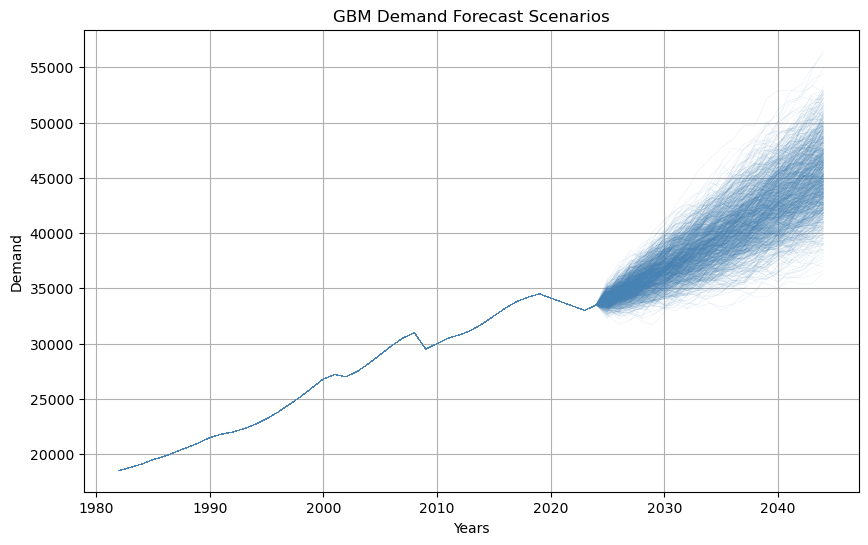

In [12]:
#Plotting to visualise
def visualiser(variablename,historicyears):
    num_years, num_scenarios  = variablename.shape
    hist_len = len(historicyears)
    future_len = num_years - hist_len
    last_year = historicyears[-1]
    future_years = np.arange(last_year + 1, last_year + 1 + future_len)
    years = np.concatenate([historicyears, future_years])
    plt.figure(figsize=(10, 6))
    for i in range(num_scenarios):
        plt.plot(years, variablename[:,i], color="steelblue", alpha=0.2,linewidth=0.25)
    plt.xlabel("Years")
    plt.ylabel("Demand")
    plt.title("GBM Demand Forecast Scenarios")
    plt.grid(True)
    plt.show()

visualiser(flights,df["Year"].values)

Exercise 1: Part 3:

For this part of the exercise, the methods used relate to that of an S-Curve. This has been chosen because historically innovations in infrastructure typically follow an S-curve pattern of growth: slow at first, then rapidly rising, before flattening out again as they reach market saturation [1]. Examples of this include that of the internet, phone lines, etc. 

This method has been chosen as it is expected that throughout the years after introduction of drones and eVTOLS the following  characteristics to be present within this market segment: 

* Learning curves - Innovation within this market segment of drones and eVTOL's is expected to lead to increased productivity and lower costs per unit over time. 
* Economies of Scale - With higher quantity levels, the cost per unit should decrease due to fixed costs being able to be spread over a greater number of units. Thus reducing the cost per unit. 
* Alongside this production cost economies of scale, purchasing economies of scale is also expected to be present. This relates to purchasing in bulk allowing bargaining powers to be applied which should reduce the costs per unit. 
* Technological reinforcement - With more supporting technologies, the demand of these vehicles is likely to increase. Similar to the electric car concept, where with more charging stations became available more people became interested into buying electric cars as the supporting network for charging had been introduced and placed. 

These being in line with the system dynamics of S-Curves as explained in [1]. 

In [13]:
def SCurve(t,q0,qt,k):
    return qt / (1+((qt -q0)/q0)*np.exp(-k*t))

def calculator(Nscr=1000,years=20,k_range=(0.08, 0.16),growth_range=(1.4, 8)):
    t = np.arange(years)
    drone = np.zeros((years, Nscr))
    evtol = np.zeros((years, Nscr))
    drone_init = 2000
    evtol_init = 1500
    for scrio in range(Nscr):
        k_drone = random.uniform(*k_range)
        k_evtol = random.uniform(*k_range)
        drone_max = drone_init * random.uniform(*growth_range)
        evtol_max = evtol_init * random.uniform(*growth_range)
        q0_drone = drone_init
        q0_evtol = evtol_init
        for year_idx, year in enumerate(t):
            drone[year_idx, scrio] = SCurve(year, q0_drone, drone_max, k_drone)
            evtol[year_idx, scrio] = SCurve(year, q0_evtol, evtol_max, k_evtol)
    return drone, evtol

drone, evtol = calculator() #Number of movements for drones and evtol scenario's

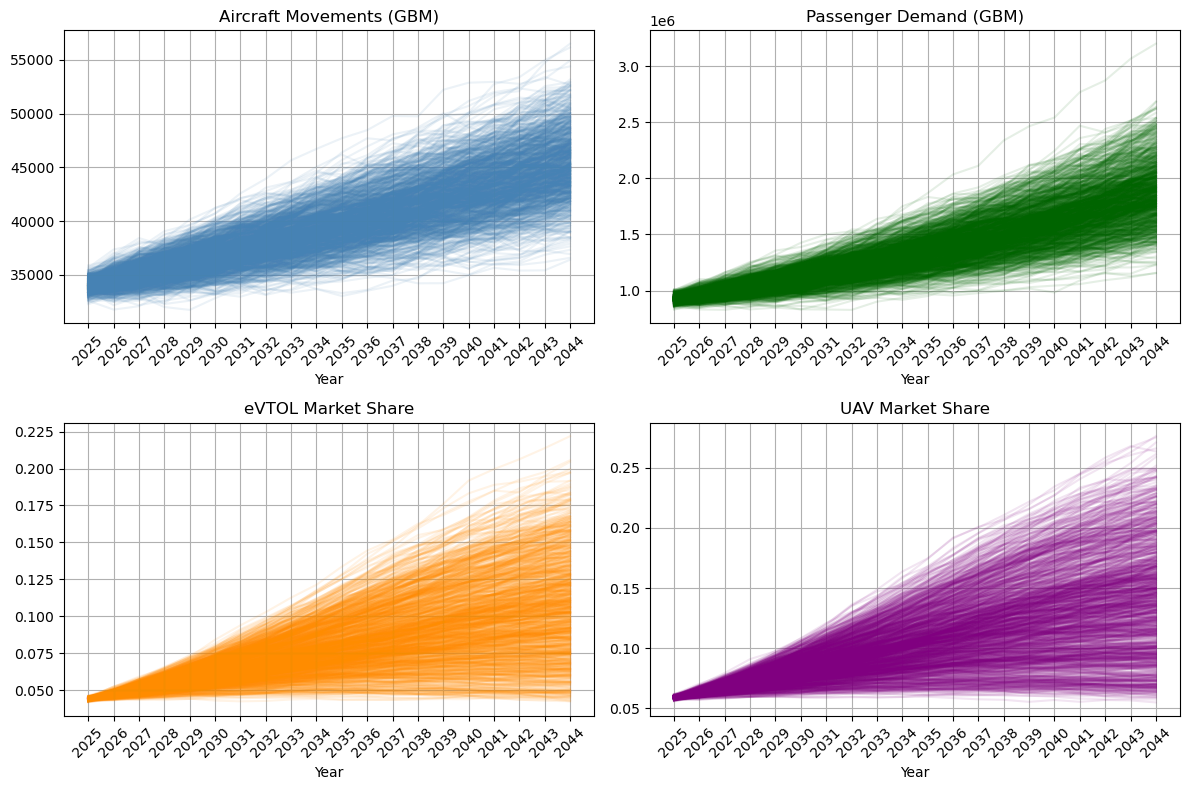

In [14]:
#Correct the forecasted GBM matrix to be able to plot with the forecasted marketshare values as they don't include historical values
hist_len = len(df["Year"].values)
forecasted_flights = flights[hist_len:, :]
forecasted_passengers = passengers[hist_len:, :]
evtol_share = evtol / forecasted_flights
drone_share = drone / forecasted_flights

def plotterthing(forecasted_flights, forecasted_passengers, evtol_share, drone_share):
    years = np.arange(2025, 2025 + forecasted_flights.shape[0])
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(years, forecasted_flights, color="steelblue", alpha=0.1)
    axes[0, 0].set_title("Aircraft Movements (GBM)")
    axes[0, 1].plot(years, forecasted_passengers, color="darkgreen", alpha=0.1)
    axes[0, 1].set_title("Passenger Demand (GBM)")
    axes[1, 0].plot(years, evtol_share, color="darkorange", alpha=0.1)
    axes[1, 0].set_title("eVTOL Market Share")
    axes[1, 1].plot(years, drone_share, color="purple", alpha=0.1)
    axes[1, 1].set_title("UAV Market Share")
    for ax in axes.flat:
        ax.set_xlabel("Year")
        ax.grid(True)
        ax.set_xticks(years)
        ax.set_xticklabels(years.astype(int), rotation=45) 
    plt.tight_layout()
    plt.show()

plotterthing(forecasted_flights, forecasted_passengers, evtol_share, drone_share)

Exercise 1: Part 4:

Identify potential real options “in” and “on” systems that could support the development of a flexible strategic plan for the airside infrastructure: 

Real options 'in' systems: 

* Dual UAV and eVTOL aprons
* Modular charging stations for eVTOL and UAV aircraft

Real options 'on' systems: 

* U-Space/ UTM integration
* Implementation plan (which go first e.g. medical or cargo only)

Exercise 1: Part 5: 

Define a candidate flexibility based upon your considerations in the previous task, which you intend to use to plan the system in a flexible manner. 

The chosen candidate flexibility: modular expansion of the charging infrastructure for both UAV and eVTOL aircraft. This allows for systematic, incremental growth in the charging capacity allowing for technological advancements in this infrastructure to be included in the growth of this market segment. As well as spread of costs over a greater period of time. 

This allings well with the real option in the system for modular charging stations. As well as with the real option on the system for implementation plan outlining the plan for the incremental phase-in of this market segment into the airport operations. 

How this operates/ can be implemented: 

* Initially upon introduction the baseline number of charging units is introduced and build. 
* This system will be designed to support future growth through the layout, parallel porting options and power supply. 
* Additional modules can be added when: 
    * Flights movements in this segment rise such that the demand exceeds 90% of provisional capacity
    * New services are introduced in this market segment (e.g. flying taxi's)
    * Fleet of aircraft using these services rises
    * Regulations allow for expansion (if initial trialling times are required by regulatory bodies)

Exercise 2: 

 Identify the operational and capital expenditures incurred by the system, their approximate magnitude, and the costs associated with capacity expansions. Identify the system’s revenue streams and describe how they can be quantified.

In [40]:
Kt_range = [35000,36000,37000,38000,39000]
Kte_range = [600, 900, 1200,1500]
growth_rate = [150,200,300,400,500,600,700,800,900,1000,1250,1500]
expand_conv = [3,4,5,6,7,8,9,10,11,12] #,13,14,15,16,17,18,19]

def Revenue(Dt, St, Kt, Kte, Rldg=749.90, Re=450):
    no_movements = np.minimum(Dt,Kt) #Limit the number of movements based on the least of the capacity of demand
    elec_movements = np.minimum(no_movements * St, Kte)
    conv_movements = no_movements - elec_movements
    R_ldg = elec_movements * Rldg + conv_movements * Rldg
    R_char_fee = elec_movements * Re
    Rev = R_ldg + R_char_fee
    return Rev

def Cost(t, Dt, Kt, Kt_prev, St, C_capex=1650, alpha=0.8, C_lease=300, C_service=250, C_fuel=175, C_charge=75,CMx=750):
    if t == 0:
        delta_capacity = Kt  # initial capacity
    else:
        delta_capacity = np.maximum(Kt - Kt_prev, 0)  # only if expanding
    CapEx = (delta_capacity ** alpha) * C_capex
    actual_movements = np.minimum(Dt, Kt)
    Excess_capacity = np.maximum(Kt - actual_movements, 0)
    MxCost = Excess_capacity * CMx
    elec_movements = actual_movements * St
    conv_movements = actual_movements * (1 - St)
    OpEx = 0
    OpEx += actual_movements * C_lease
    OpEx += conv_movements * (C_fuel + C_service)
    OpEx += elec_movements * C_charge #add something that adds costs if stand is not used
    TotalCost = CapEx + OpEx + MxCost
    return TotalCost

#Exercise 7 ENPV calculations
#Conventional approach with real options
def ENPV(flights, drone, evtol, Kt0, Kte0, t_expand=None, Ktexpan=1.20, r=0.07):
    years = flights.shape[0]
    Nscr = flights.shape[1]
    npvs = np.zeros(Nscr)
    Kt_prev = np.full(Nscr, Kt0)
    Kte_prev = np.full(Nscr, Kte0)
    kt_plot = np.zeros((years, Nscr))
    demand_plot = np.zeros((years, Nscr))
    discount_factors = 1 / ((1 + r) ** np.arange(1, years + 1))
    for t in range(years):
        Dt = flights[t]
        St = np.where(Dt > 0, (drone[t] + evtol[t]) / Dt, 0)
        St = np.clip(St, 0, 1)
        if t_expand is not None and t >= t_expand:
            Kt_current = np.full(Nscr, Kt0*Ktexpan)
            Kte_current = np.full(Nscr, Kte0*Ktexpan)
        else:
            Kt_current = Kt_prev
            Kte_current = Kte_prev
        R = Revenue(Dt, St, Kt_current, Kte_current)
        C = Cost(t, Dt, Kt_current, Kt_prev, St)
        npvs += (R - C) * discount_factors[t]
        Kt_prev = Kt_current.copy()
        Kte_prev = Kte_current.copy()
        kt_plot[t, :] = Kt_prev + Kte_prev
        demand_plot[t, :] = Dt
    return npvs, t_expand,kt_plot, demand_plot

def find_best_capacities(flights, drone, evtol, Kt_range, Kte_range):
    best_enpv = -np.inf
    best_combo = None
    for year in expand_conv:
        for Kt in Kt_range:
            for Kte in Kte_range:
                npvs,_,_,_ = ENPV(flights, drone, evtol, Kt, Kte,year)
                val = np.mean(npvs)
                if val > best_enpv:
                    best_enpv = val
                    best_combo = (Kt, Kte)
                    best_year = year
    return best_combo,best_year,best_enpv

best_capacities, best_year, best_value = find_best_capacities(forecasted_flights, drone, evtol, Kt_range, Kte_range)
print('Regular ENPV')
print('Pair shows: Best initial capacity for conventional aircraft, Best initial capacity for electric aircraft')
print("Best Kt, Kte:", best_capacities)
print("Best expansion year:", best_year)
print("Best ENPV:", best_value)

convenpv, _,Ktreturnconv, Dtreturnconv = ENPV(forecasted_flights, drone, evtol,best_capacities[0], best_capacities[1],t_expand=best_year)
best_idx_1 = np.argmax(convenpv)

# Flexible approach based on the candidate flexibility defined in Task 4:
# Defined flexibility: Modular charging stations for electric aircraft. 

def bestFlexENPV(flights, drone, evtol, Kt_range, Kte_range,growth_range):
    best_enpv = -np.inf
    best_combo = None
    for Kt in Kt_range:
        for Kte in Kte_range:
            for growth in growth_range:
                npvs, _, _ = (ENPV_Flex(flights, drone, evtol, Kt, Kte,growth))
                val = np.mean(npvs)
                if val > best_enpv:
                    best_enpv = val
                    best_combo = (Kt, Kte,growth)
    return best_combo, best_enpv

def ENPV_Flex(flights, drone, evtol, Kt, Kte, Ktexpan,r=0.07):
    years, Nscr = flights.shape
    npvs = np.zeros(Nscr)
    kt_plot = np.zeros((years, Nscr))
    demand_plot = np.zeros((years, Nscr))
    Kt_prev = np.full(Nscr,Kt)
    Kte_prev = np.full(Nscr, Kte)
    Kt_total_prev = Kt_prev + Kte_prev
    discount_factors = 1 / ((1 + r) ** np.arange(1, years + 1))
    for t in range(years):  
        Dt = flights[t, :]
        St = np.where(Dt > 0, (drone[t, :] + evtol[t, :]) / Dt, 0)
        expand = (St > 0.25) & (Dt > Kt_total_prev*1.05)
        Kt_current = Kt_prev + Ktexpan* expand.astype(int) #Conventional aircraft 
        Kte_current = Kte_prev + Ktexpan * expand.astype(int) #Electric vehicles
        Kt_total_current = Kt_current + Kte_current
        R = Revenue(Dt, St, Kt_current, Kte_current)
        C = Cost(t, Dt, Kt_current, Kt_prev, St)      
        npvs += (R - C) * discount_factors[t]
        Kt_prev = Kt_current.copy()
        Kte_prev = Kte_current.copy()
        Kt_total_prev = Kt_total_current.copy()
        kt_plot[t, :] = Kt_total_current
        demand_plot[t, :] = Dt
    return npvs, kt_plot, demand_plot

best_capacities, best_value = bestFlexENPV(forecasted_flights, drone, evtol, Kt_range, Kte_range,growth_rate)
print('Flexible ENPV:')
print('Pair shows: Best initial capacity for conventional aircraft, Best inital capacity for electric aircraft, Best capacity increase vector')
print("Best Kt, Kte:", best_capacities)
print("Best ENPV:", best_value)

flexenpv, Ktreturnflex, Dtreturnflex = ENPV_Flex(forecasted_flights, drone, evtol, best_capacities[0], best_capacities[1],best_capacities[2])
best_idx_2 = np.argmax(flexenpv)

Regular ENPV
Pair shows: Best initial capacity for conventional aircraft, Best initial capacity for electric aircraft
Best Kt, Kte: (35000, 1500)
Best expansion year: 12
Best ENPV: 28793555.93225817
Flexible ENPV:
Pair shows: Best initial capacity for conventional aircraft, Best inital capacity for electric aircraft, Best capacity increase vector
Best Kt, Kte: (35000, 1500, 1500)
Best ENPV: 30194932.32843475


Comparing the optimal ENPV values: 

* ENPV works well for forecasts with low variance, so when excluding the COVID years, it yields higher results compared to flexible ENPV.
* When including the COVID years, the flexible is much better the conventional method however with smaller margin. In other words, the net present value is higher for lower cumulative probabilities when using the flexible method compared to the conventional method at lower probabilities (0-0.5)

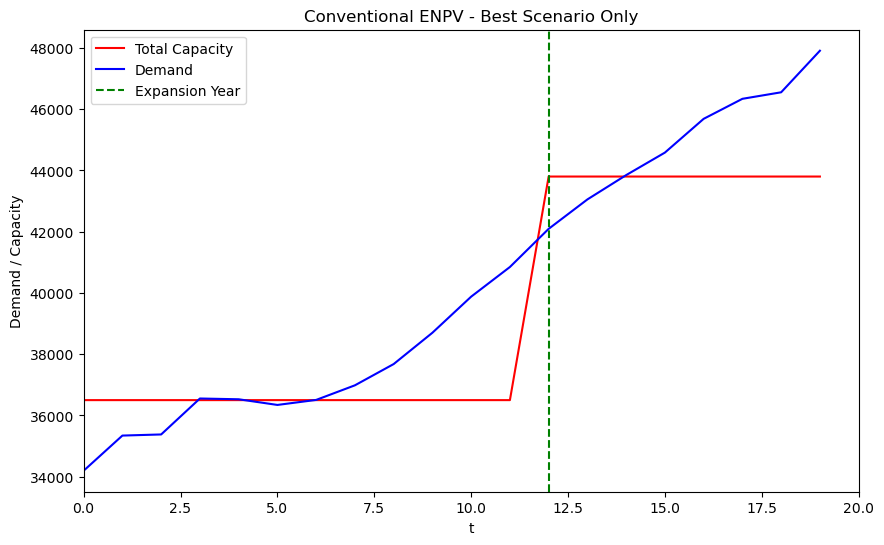

In [41]:
plt.figure(figsize=(10,6))
plt.plot(Ktreturnconv[:, best_idx_1], 'r', label='Total Capacity')
plt.plot(Dtreturnconv[:, best_idx_1], 'b', label='Demand')
plt.axvline(x=best_year, color='g', linestyle='--', label='Expansion Year')
plt.xlim(0,Dtreturnconv.shape[0])
plt.legend()
plt.xlabel("t")
plt.ylabel("Demand / Capacity")
plt.title("Conventional ENPV - Best Scenario Only")
plt.show()

<Figure size 1000x600 with 0 Axes>

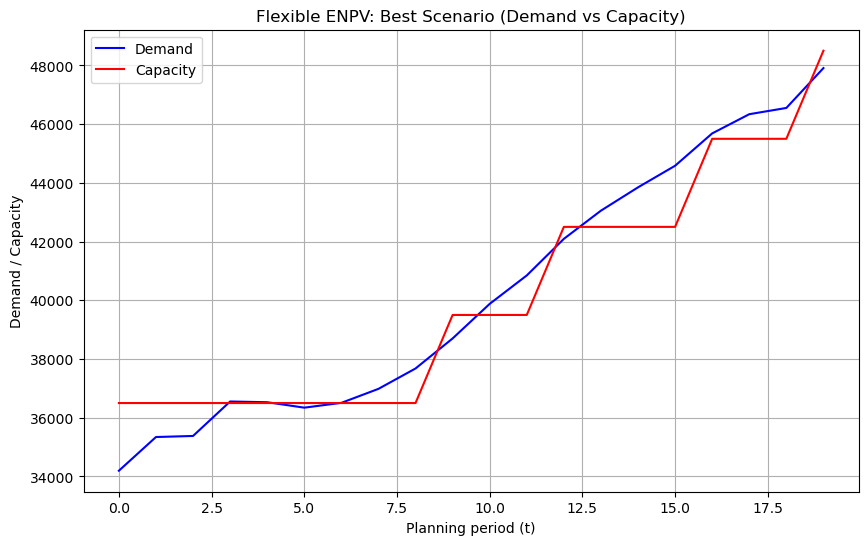

In [42]:
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
years = Dtreturnflex.shape[0]
t = np.arange(years)
plt.plot(t, Dtreturnflex[:, best_idx_2], color='blue', label='Demand')
plt.plot(t, Ktreturnflex[:, best_idx_2], color='red', label='Capacity')
plt.xlabel('Planning period (t)')
plt.ylabel('Demand / Capacity')
plt.title('Flexible ENPV: Best Scenario (Demand vs Capacity)')
plt.legend()
plt.grid(True)
plt.show()

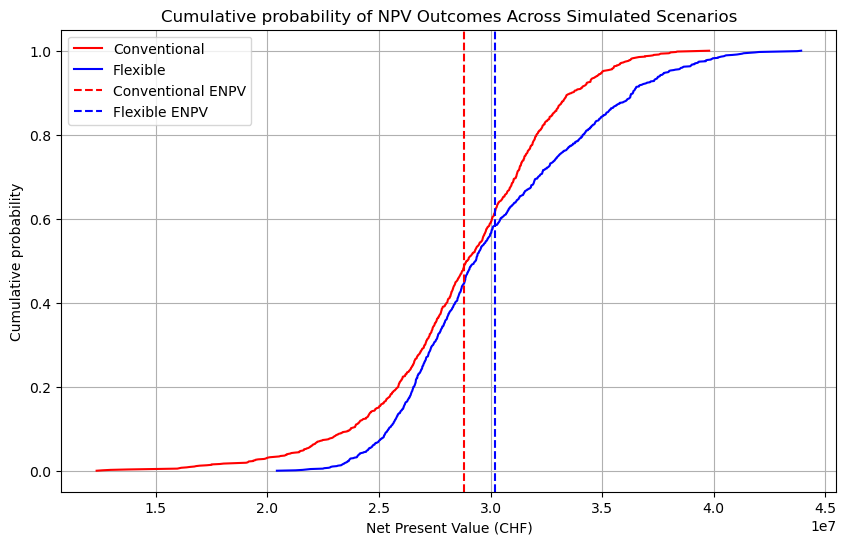

In [43]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_conv, y_conv = ecdf(convenpv)
x_flex, y_flex = ecdf(flexenpv)

plt.figure(figsize=(10,6))
plt.plot(x_conv, y_conv, color='red', label='Conventional')
plt.plot(x_flex, y_flex, color='blue', label='Flexible')
plt.axvline(np.mean(convenpv), color='red', linestyle='--', linewidth=1.5,label=f'Conventional ENPV')
plt.axvline(np.mean(flexenpv), color='blue', linestyle='--', linewidth=1.5,label=f'Flexible ENPV')
plt.xlabel("Net Present Value (CHF)")
plt.ylabel("Cumulative probability")
plt.title("Cumulative probability of NPV Outcomes Across Simulated Scenarios")
plt.grid(True)
plt.legend()
plt.show()


References:

[1] L. Speelman and Y. Numata, “A theory of rapid transition: How S-Curves work and what we can do to accelerate them,” Oct. 2022. https://rmi.org/wp-content/uploads/2022/10/theory_of_rapid_transition_how_s_curves_work.pdf